In [1]:
import os
import sys
sys.path.append(r'../')
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import pandas as pd

from src.d_CSL import GcStar
from src.d_CSL import Visualize_on_topography
from src.dataload import *
from src.dataPreProcessing import replace_nan


# Remove null values df. dropna(inplace=True)

# if variables are changed on the fly 
# from reloading import reloading
from tqdm.notebook import tqdm

In [2]:
%reload_ext autoreload
%autoreload 2
from src.d_CSL import *

In [3]:
N_PASTS, n_lags, n_perm = [5, 10], 1, 1000
alpha, beta = 0.01, 0.001

In [4]:
%%time

# load data
os.chdir(r'./data/Sachs_data/')
names = [n for n in os.listdir() if n.endswith('.xls')]
INFs = {}
for i in range(len(names)):
    data = pd.read_excel(names[i])
    X_ = data.values
    X = X_.T
    print('Data ' + names[i] + ' , with len = {}'.format({X.shape[1]}))
    print('')
    
    # Analysis
    infs = []
    for a, n in enumerate(N_PASTS):
        
        print(f'{n} pasts')
        gcstar = GcStar(n_perm = 1000, 
                    n_pasts = n, 
                    n_lags = n_lags,
                    temporal = True,
                    method = ' ')
    
        gcstar.fit(X, verbose = 0)
        inf = gcstar.get_connectivity_matrix(simulation=False)
        np.fill_diagonal(inf, 0)
        infs.append(inf)
        # gcstar.plot_extended_connectivity_matrix(alpha = 0.01, beta = 0.001)

    print('')
    print('')
    INFs[i] = infs

Data 6. cd3cd28+u0126.xls , with len = {799}

5 pasts
10 pasts


Data 1. cd3cd28.xls , with len = {853}

5 pasts
10 pasts


Data 10. cd3cd28icam2+aktinhib.xls , with len = {899}

5 pasts
10 pasts


Data 2. cd3cd28icam2.xls , with len = {902}

5 pasts
10 pasts


Data 13. cd3cd28icam2+u0126.xls , with len = {759}

5 pasts
10 pasts


Data 8. pma.xls , with len = {913}

5 pasts
10 pasts


Data 3. cd3cd28+aktinhib.xls , with len = {911}

5 pasts
10 pasts


Data 14. cd3cd28icam2+ly.xls , with len = {927}

5 pasts
10 pasts


Data 4. cd3cd28+g0076.xls , with len = {723}

5 pasts
10 pasts


Data 11. cd3cd28icam2+g0076.xls , with len = {753}

5 pasts
10 pasts


Data 9. b2camp.xls , with len = {707}

5 pasts
10 pasts


Data 7. cd3cd28+ly.xls , with len = {848}

5 pasts
10 pasts


Data 5. cd3cd28+psitect.xls , with len = {810}

5 pasts
10 pasts


Data 12. cd3cd28icam2+psit.xls , with len = {868}

5 pasts
10 pasts


CPU times: user 17min 14s, sys: 1min 48s, total: 19min 2s
Wall time: 16min 49s


In [5]:
pro = ['Raf', 'Mek', 'P1cy', 'PIP2', 'PIP3', 'p44/42', 'Akt', 'PKA', 'PKC', 'p38', 'Jnk']

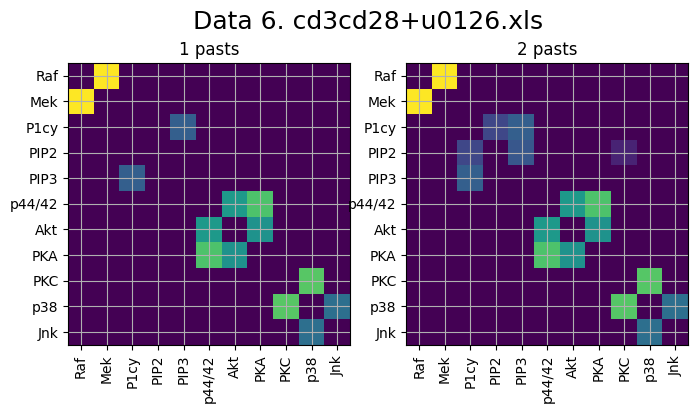

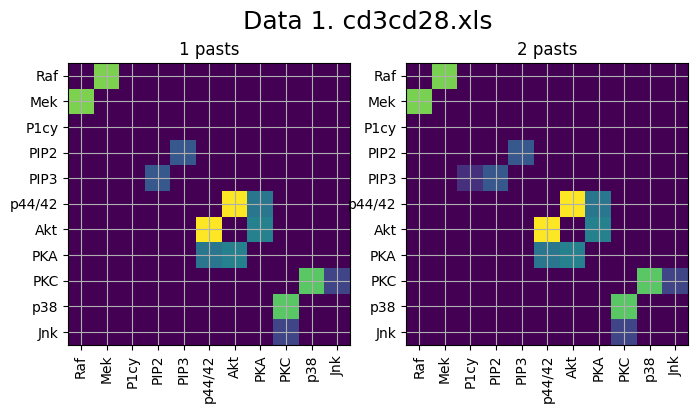

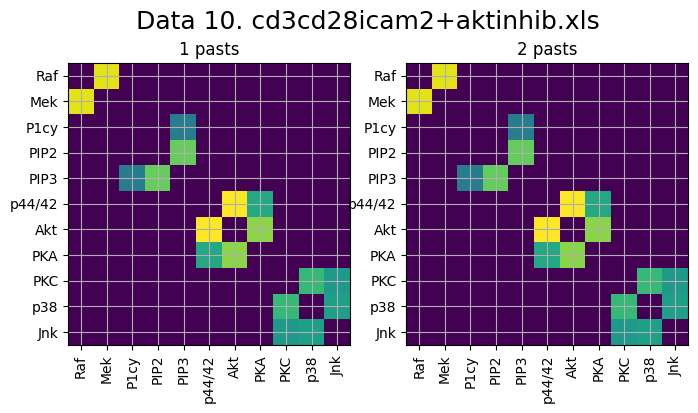

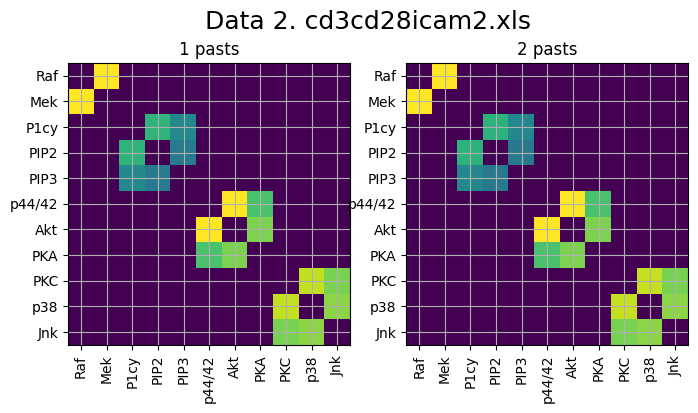

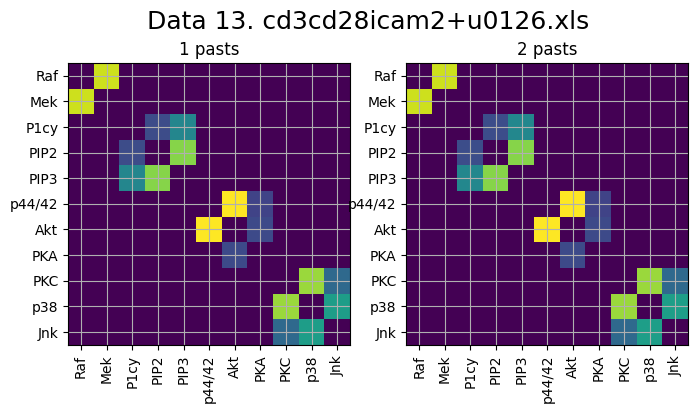

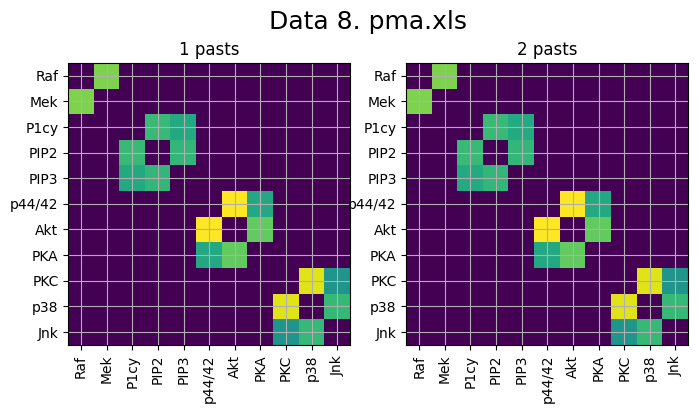

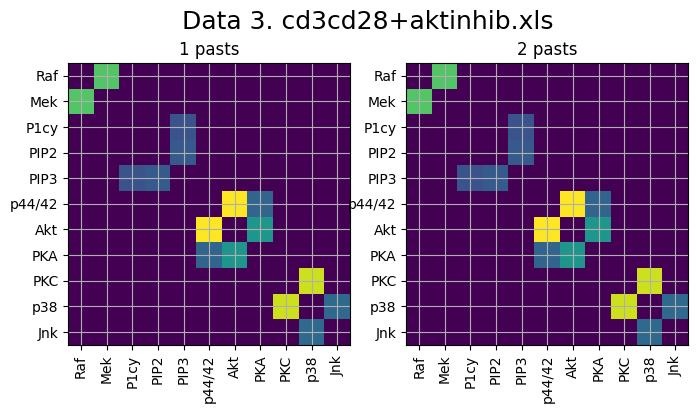

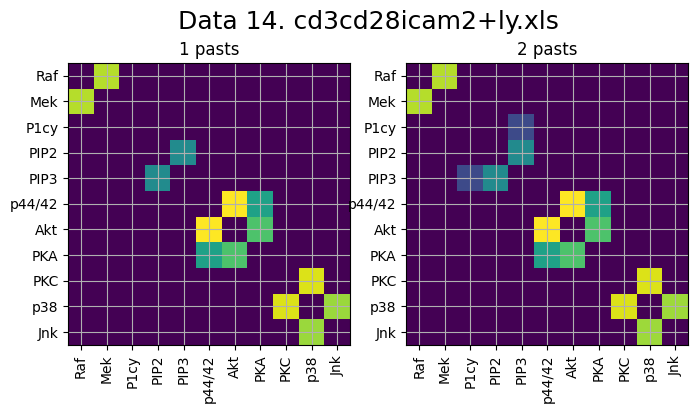

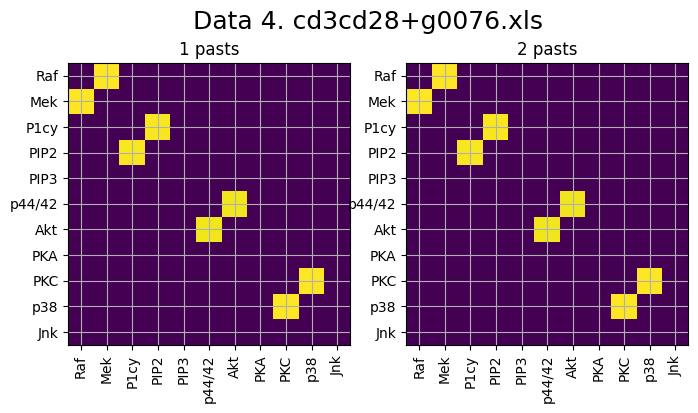

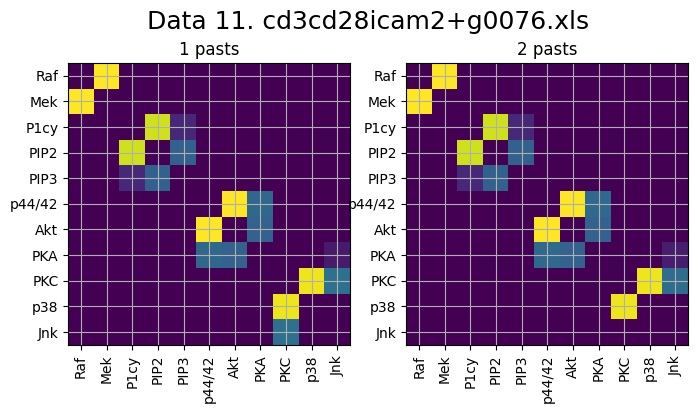

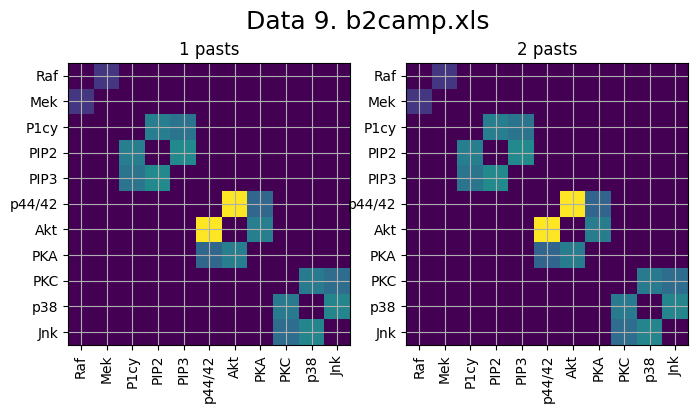

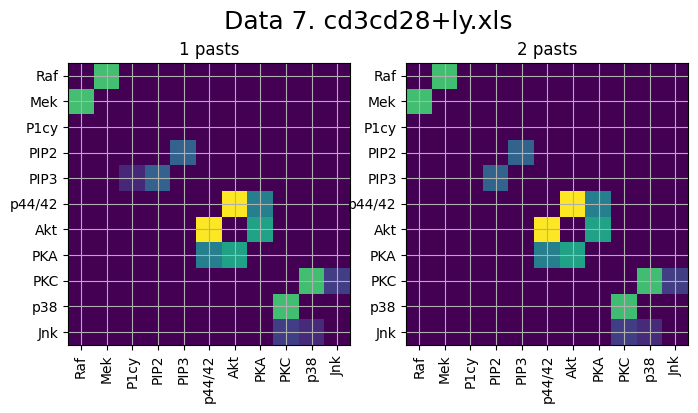

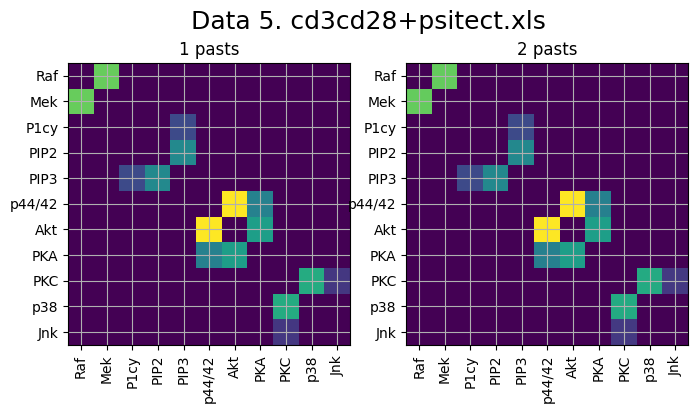

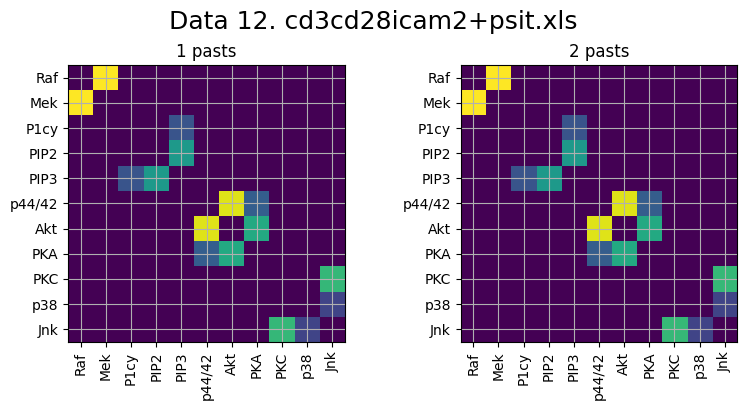

In [6]:
for i in range(14):
  fig,ax = plt.subplots(1,2,figsize=(8,4))
  for j in range(2):
    ax[j].imshow(INFs[i][j])
    ax[j].set_title(f'{j+1} pasts')
    ax[j].set_xticks(np.arange(INFs[i][j].shape[0]))
    ax[j].set_yticks(np.arange(INFs[i][j].shape[0]))
    ax[j].set_xticklabels(pro,rotation=90)
    ax[j].set_yticklabels(pro)
    ax[j].grid()
  plt.suptitle(f'Data {names[i]}', fontsize=18)
plt.tight_layout()